In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, Bidirectional
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
from tqdm import tqdm

In [ ]:
# Go two levels up from DeepLearning to reach Bookify
BASE_DIR = os.getcwd()

# Correct path to Database/Cleaned_Datasets
DATA_DIR = os.path.normpath(os.path.join(BASE_DIR, '..', '..', 'Database', 'Cleaned_Datasets'))


#Define Model directory
MODEL_DIR = os.path.normpath(os.path.join(BASE_DIR, '..', '..', 'Models'))

In [3]:
SENTIMENT_DATA_PATH = os.path.join(DATA_DIR, "processed_reviews_with_embeddings_and_sentiment.csv")

# Load the cleaned review dataset
df = pd.read_csv(SENTIMENT_DATA_PATH)

In [4]:
# Show basic info and first few rows
df.head()
print(df.shape)
print(df['sentiment'].value_counts())

(74907, 16)
sentiment
positive    56107
negative    16286
neutral      2514
Name: count, dtype: int64


In [5]:
# Encode sentiment labels into numeric values (e.g., positive=2, negative=0, neutral=1)
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

print(dict(zip(le.classes_, le.transform(le.classes_))))
print(df[['sentiment', 'sentiment_encoded']].head())

{'negative': 0, 'neutral': 1, 'positive': 2}
  sentiment  sentiment_encoded
0  positive                  2
1  positive                  2
2  positive                  2
3  negative                  0
4  positive                  2


In [6]:
texts = df['cleaned_text'].astype(str).values
labels = df['sentiment_encoded'].values

print(f"Total samples: {len(texts)}")
print(f"Sample text: {texts[0]}")
print(f"Sample label: {labels[0]}")


Total samples: 74907
Sample text: jace rankin may be short but hes nothing to mess with as the man who was just hauled out of the saloon by the undertaker knows now hes a famous bounty hunter in oregon in the s who when he shot the man in the saloon just finished a years long quest to avenge his sisters murder and is now trying to figure out what to do next when the snottynosed farm boy he just rescued from a gang of bullies offers him money to kill a man who forced him off his ranch he reluctantly agrees to bring the man to justice but not to kill him outright but first he needs to tell his sisters widower the newskyla kyle springer bailey has been riding the trails and sleeping on the ground for the past month while trying to find jace she wants revenge on the man who killed her husband and took her ranch amongst other crimes and shes not so keen on the detour jace wants to take but she realizes shes out of options so she hides behind her boy persona as best she can and tries to keep

In [7]:
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

print(f"Example sequence (first review): {sequences[0]}")
print(f"Padded sequence shape: {padded_sequences.shape}")

Example sequence (first review): [9345, 194, 25, 228, 16, 234, 219, 5, 2002, 14, 17, 1, 142, 44, 12, 47, 56, 3, 1, 38, 1, 465, 124, 234, 4, 933, 8378, 2626, 7, 9609, 7, 1, 257, 44, 50, 23, 1473, 1, 142, 7, 1, 47, 599, 4, 131, 176, 1561, 5, 22, 1256, 549, 2, 8, 124, 287, 5, 753, 56, 43, 5, 75, 222, 50, 1, 2129, 421, 23, 47, 4851, 36, 4, 3126, 3, 6949, 1400, 78, 476, 5, 775, 4, 142, 44, 824, 78, 174, 22, 6919, 23, 7382, 4212, 5, 688, 1, 142, 5, 1051, 16, 21, 5, 775, 78, 5753, 16, 76, 23, 546, 5, 307, 22, 1256, 1, 7341, 48, 84, 4120, 1, 2, 2723, 20, 1, 1516, 13, 1, 294, 1567, 123, 287, 5, 140, 28, 423, 1742, 20, 1, 142, 44, 774, 18, 534, 2, 347, 18, 6919, 3354, 81, 2224, 2, 270, 21, 29, 3756, 20, 1, 423, 5, 187, 16, 28, 2160, 270, 56, 3, 4240, 29, 28, 6271, 527, 18, 421, 3533, 17, 164, 28, 62, 2, 990, 5, 266, 1298, 50, 4, 6420, 355, 1, 87, 338, 18, 1473, 2, 1839, 9, 4, 28, 48, 5, 185, 2118, 33, 1, 245, 353, 28, 546, 11, 471, 2, 358, 562, 118, 250, 15, 48, 39, 905, 3, 1992, 606, 2, 308, 54

In [8]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(padded_sequences, labels)

print("Before SMOTE:", dict(zip(*np.unique(labels, return_counts=True))))
print("After SMOTE:", dict(zip(*np.unique(y_resampled, return_counts=True))))
print(f"Resampled data shape: {X_resampled.shape}")


Before SMOTE: {0: 16286, 1: 2514, 2: 56107}
After SMOTE: {0: 56107, 1: 56107, 2: 56107}
Resampled data shape: (168321, 100)


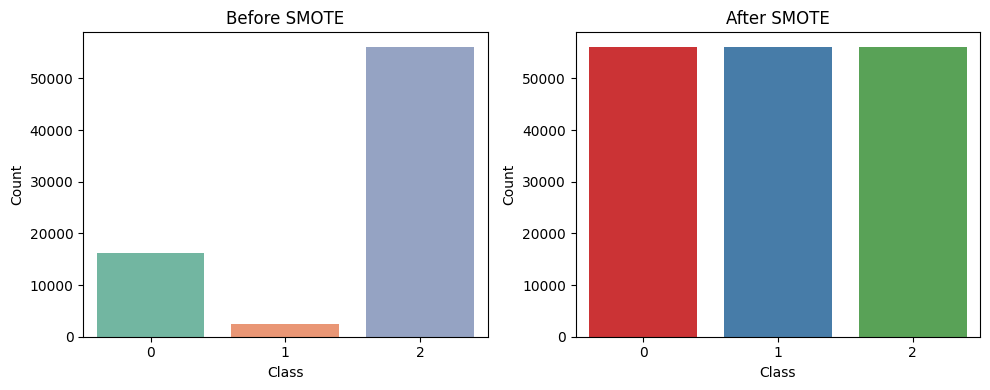

In [9]:
# Before SMOTE
labels_unique, labels_counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=labels_unique, y=labels_counts, palette="Set2")
plt.title("Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

# After SMOTE
resampled_unique, resampled_counts = np.unique(y_resampled, return_counts=True)
plt.subplot(1, 2, 2)
sns.barplot(x=resampled_unique, y=resampled_counts, palette="Set1")
plt.title("After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [10]:
#Split Train and Validation Sets
X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

Training samples: 134656, Validation samples: 33665


In [11]:
# Build and Compile LSTM Model
embedding_dim = 128

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),    # Capture both directions
    Dropout(0.5),
    LSTM(32),                                           # Additional LSTM layer for depth
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')                      # 3 sentiment classes
])

In [12]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [13]:
# Train LSTM Model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/15
2104/2104 ━━━━━━━━━━━━━━━━━━━━ 343s 162ms/step - accuracy: 0.6017 - loss: 0.8812 - val_accuracy: 0.7597 - val_loss: 0.5595
Epoch 2/15
2104/2104 ━━━━━━━━━━━━━━━━━━━━ 320s 152ms/step - accuracy: 0.7605 - loss: 0.5717 - val_accuracy: 0.7828 - val_loss: 0.4971
Epoch 3/15
2104/2104 ━━━━━━━━━━━━━━━━━━━━ 394s 186ms/step - accuracy: 0.7969 - loss: 0.4834 - val_accuracy: 0.7910 - val_loss: 0.4912
Epoch 4/15
2104/2104 ━━━━━━━━━━━━━━━━━━━━ 225s 107ms/step - accuracy: 0.8173 - loss: 0.4343 - val_accuracy: 0.7988 - val_loss: 0.4753
Epoch 5/15
2104/2104 ━━━━━━━━━━━━━━━━━━━━ 200s 95ms/step - accuracy: 0.8328 - loss: 0.3994 - val_accuracy: 0.7924 - val_loss: 0.5072
Epoch 6/15
2104/2104 ━━━━━━━━━━━━━━━━━━━━ 203s 96ms/step - accuracy: 0.8492 - loss: 0.3645 - val_accuracy: 0.7841 - val_loss: 0.5296
Epoch 7/15
2104/2104 ━━━━━━━━━━━━━━━━━━━━ 276s 131ms/step - accuracy: 0.8643 - loss: 0.3346 - val_accuracy: 0.7879 - val_loss: 0.5670


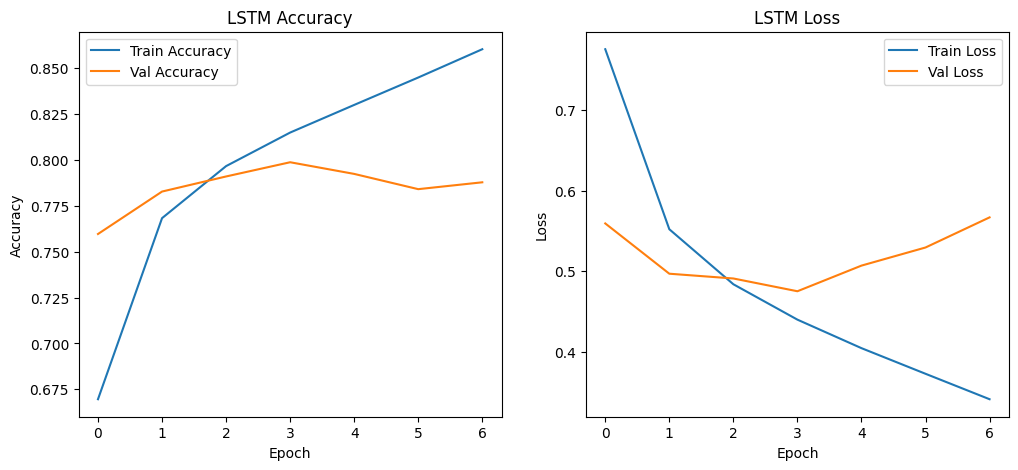

In [14]:
# Plot LSTM Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [15]:
# Predict class probabilities for validation set
y_val_pred_probs = model.predict(X_val)
# Convert probs to predicted classes
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

print("LSTM Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

print("LSTM Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

1053/1053 ━━━━━━━━━━━━━━━━━━━━ 33s 31ms/step
LSTM Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.70      0.71     11221
     neutral       0.82      0.78      0.80     11222
    positive       0.84      0.92      0.88     11222

    accuracy                           0.80     33665
   macro avg       0.80      0.80      0.80     33665
weighted avg       0.80      0.80      0.80     33665

LSTM Confusion Matrix:
[[ 7829  1774  1618]
 [ 2171  8749   302]
 [  755   154 10313]]


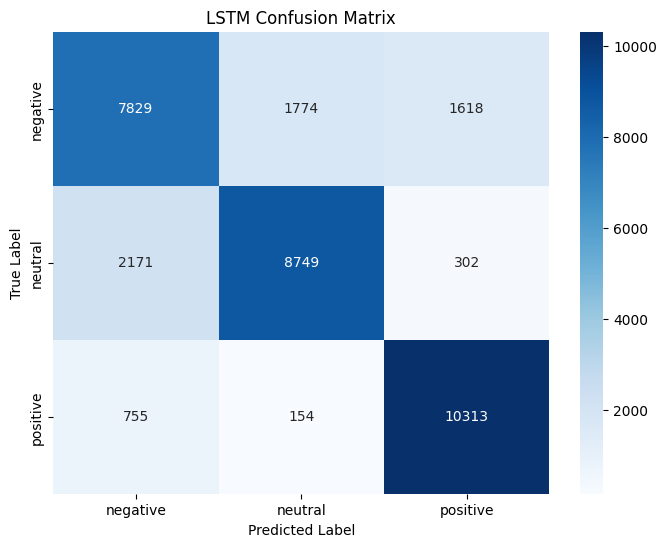

In [16]:
# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LSTM Confusion Matrix")
plt.show()

In [18]:
lstm_model_dir = os.path.join(MODEL_DIR, "lstm_model_v1.h5")
model.save(lstm_model_dir)
print(f"LSTM model saved at: {lstm_model_dir}")

LSTM model saved at: c:\Users\HP\Desktop\Bookify\Models\lstm_model_v1.h5
